In [186]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'


In [187]:
def get_sorted_columns(data, name='train-top5-acc'):
    columns = [col for col in data.columns if name in col and "__" not in col]
    index = [int(column.split(" - ")[0].split('-')[-1])for column in columns]

    zipped_value = zip(columns,index)
    sorted_zipped_value = sorted(zipped_value, key=lambda x:x[1])

    sorted_columns, sorted_index = zip(*sorted_zipped_value)

    return sorted_columns

def get_concatenated_data(data, name='train-top5-acc'):

    sorted_columns = get_sorted_columns(data,name)
    concatenated_values = pd.concat([data[column] for column in sorted_columns]).dropna()

    return concatenated_values

def remove_epoch_overlap_single(metric_series, vanilla_training):
    cleaned_epoch_indices = []

    for key in vanilla_training.keys():
        run_info = vanilla_training[key]

        if len(cleaned_epoch_indices) == 0:
            for value in range(run_info['start'],run_info['end']+ 1 - run_info['remove']):
                cleaned_epoch_indices.append(value)
        else:
            total_cleaned_epochs = len(cleaned_epoch_indices)
            start_info = run_info['start']
            skip_values = total_cleaned_epochs - start_info + 1

            for value in range(total_cleaned_epochs + skip_values - 1 - run_info['remove'], run_info['end'] + skip_values - run_info['remove']):
                cleaned_epoch_indices.append(value)
            
    # Convert to list or numpy array if it's a Series
    if isinstance(metric_series, pd.Series):
        metric_series = metric_series.to_numpy()

    return [metric_series[i] for i in cleaned_epoch_indices]


def merge_data(all_data_points, merge_data_points, merge_info):

    merged_values = all_data_points

    for key in merge_info.keys():
        start_value = merge_info[key]['start']
        
        if start_value > len(all_data_points):

            merged_values = all_data_points + merge_data_points
        else:

            merged_values = merged_values[:start_value] + merge_data_points

    return merged_values

### Full Model Run Preprocessing (Full Training 300 epochs)

In [188]:
# Load the CSV file
train_top1_acc = pd.read_csv("exp_base/train_top1_acc.csv")
train_top5_acc = pd.read_csv("exp_base/train_top5_acc.csv")

valid_top1_acc = pd.read_csv("exp_base/valid_top1_acc.csv")
valid_top5_acc = pd.read_csv("exp_base/valid_top5_acc.csv")

train_loss = pd.read_csv("exp_base/train_loss.csv")
train_epoch_time = pd.read_csv("exp_base/epoch_time.csv")


In [189]:
train_top5_all = get_concatenated_data(train_top5_acc, 'train-top5-acc')
train_top1_all = get_concatenated_data(train_top1_acc, 'train-top1-acc')
valid_top5_all = get_concatenated_data(valid_top5_acc, 'top5_val_acc')
valid_top1_all = get_concatenated_data(valid_top1_acc, 'top1_val_acc')
train_loss_all = get_concatenated_data(train_loss, 'loss')
train_epoch_time_all = get_concatenated_data(train_epoch_time,'epoch_time')

In [190]:
vanilla_training = {
    1: {'start' : 0, 'end': 57, 'remove':0},
    2: {'start' : 56, 'end': 113, 'remove':0},
    3: {'start' : 111, 'end': 168, 'remove':0},
    4: {'start' : 166, 'end': 222, 'remove':0},
    5: {'start' : 221, 'end': 280, 'remove':0},
    6: {'start' : 281, 'end': 299, 'remove':0},
    }

train_top5_all = remove_epoch_overlap_single(train_top5_all, vanilla_training)
train_top1_all = remove_epoch_overlap_single(train_top1_all, vanilla_training)
valid_top5_all = remove_epoch_overlap_single(valid_top5_all, vanilla_training)
valid_top1_all = remove_epoch_overlap_single(valid_top1_all, vanilla_training)
train_loss_all = remove_epoch_overlap_single(train_loss_all, vanilla_training)
train_epoch_time_all = remove_epoch_overlap_single(train_epoch_time_all, vanilla_training)
train_epoch_time_all = [value + 125 for value in train_epoch_time_all]


In [191]:
def remove_overlap(data, different_runs, final_merge, name='', run_start_idx = 51):
    cleaned_epoch_indices = []
    stitched_range = set()  # track all epochs we've already included

    sorted_columns = get_sorted_columns(data, name)

    for index, column in enumerate(sorted_columns):
        selected_data = list(data[column].dropna().values)
        start, end = different_runs[index]

        # Build corresponding epoch indices for this run
        epoch_indices = list(range(start, end + 1))

        # Filter out epochs already included
        new_epochs = [ep for ep in epoch_indices if ep not in stitched_range]

        # Map back into selected_data (keep alignment)
        keep_count = len(new_epochs)
        if keep_count > 0:
            # Align from the right: keep the last `keep_count` values
            selected_data = selected_data[-keep_count:]
            cleaned_epoch_indices.extend(selected_data)

            # Update stitched_range
            stitched_range.update(new_epochs)

    all_value = []
    all_value.extend(final_merge[:run_start_idx])
    all_value.extend(cleaned_epoch_indices)
    
    print(f"Len of {name} is: {len(all_value)}")

    return all_value


def get_run_count(data, name='epoch'):
    sorted_columns = get_sorted_columns(data,name)
    all_runs = []
    for column in sorted_columns:
        na_dropped = data[column]
        all_runs.append((int(na_dropped.min()), int(na_dropped.max())))

    return all_runs

### Exp_1 starting at 50 (1_5)


In [192]:
# Load the CSV file
exp_1_train_t1 = pd.read_csv("exp_1_5/train_top_1.csv")
exp_1_train_t5 = pd.read_csv("exp_1_5/train_top_5.csv")

exp_1_valid_t5 = pd.read_csv("exp_1_5/valid_top_5.csv")
exp_1_valid_t1 = pd.read_csv("exp_1_5/valid_top_1.csv")

exp_1_loss = pd.read_csv("exp_1_5/loss.csv")
exp_1_epoch_time = pd.read_csv("exp_1_5/epoch_time.csv")

exp_1_epochs = pd.read_csv("exp_1_5/epochs.csv")


In [193]:
exp1_epoch_runs = get_run_count(exp_1_epochs,'epoch')
print(exp1_epoch_runs)

exp_1_full_train_t5 = remove_overlap(exp_1_train_t5, exp1_epoch_runs, train_top5_all, 'train-top5-acc')
exp_1_full_train_t1 = remove_overlap(exp_1_train_t1, exp1_epoch_runs, train_top1_all, 'train-top1-acc')
exp_1_full_valid_t5 = remove_overlap(exp_1_valid_t5, exp1_epoch_runs, valid_top5_all, 'top5_val_acc')
exp_1_full_valid_t1 = remove_overlap(exp_1_valid_t1, exp1_epoch_runs, valid_top1_all, 'top1_val_acc')
exp_1_full_loss = remove_overlap(exp_1_loss,exp1_epoch_runs, train_loss_all, 'loss')
exp_1_full_epoch_time = remove_overlap(exp_1_epoch_time,exp1_epoch_runs,train_epoch_time_all, 'epoch_time')

[(51, 83), (81, 114), (111, 124), (126, 235), (236, 299)]
Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Exp_2 starting at 50 (0.5_2.5)

In [194]:
# Load the CSV file
exp_2_train_t1 = pd.read_csv("exp_0.5_2.5/train_top_1.csv")
exp_2_train_t5 = pd.read_csv("exp_0.5_2.5/train_top_5.csv")

exp_2_valid_t5 = pd.read_csv("exp_0.5_2.5/valid_top_5.csv")
exp_2_valid_t1 = pd.read_csv("exp_0.5_2.5/valid_top_1.csv")

exp_2_loss = pd.read_csv("exp_0.5_2.5/loss.csv")
exp_2_epoch_time = pd.read_csv("exp_0.5_2.5/epoch_time.csv")

exp_2_epochs = pd.read_csv("exp_0.5_2.5/epochs.csv")


exp2_epoch_runs = get_run_count(exp_2_epochs,'epoch')

exp_2_full_train_t5 = remove_overlap(exp_2_train_t5, exp2_epoch_runs, train_top5_all, 'train-top5-acc')
exp_2_full_train_t1 = remove_overlap(exp_2_train_t1, exp2_epoch_runs, train_top1_all, 'train-top1-acc')
exp_2_full_valid_t5 = remove_overlap(exp_2_valid_t5, exp2_epoch_runs, valid_top5_all, 'top5_val_acc')
exp_2_full_valid_t1 = remove_overlap(exp_2_valid_t1, exp2_epoch_runs, valid_top1_all, 'top1_val_acc')
exp_2_full_loss = remove_overlap(exp_2_loss,exp2_epoch_runs, train_loss_all, 'loss')
exp_2_full_epoch_time = remove_overlap(exp_2_epoch_time,exp2_epoch_runs, train_epoch_time_all, 'epoch_time')


Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Exp_3 starting at 50 (0.25_1_a)

In [195]:
# Load the CSV file
exp_3_train_t1 = pd.read_csv("exp_0.25_1/train_top_1.csv")
exp_3_train_t5 = pd.read_csv("exp_0.25_1/train_top_5.csv")

exp_3_valid_t5 = pd.read_csv("exp_0.25_1/valid_top_5.csv")
exp_3_valid_t1 = pd.read_csv("exp_0.25_1/valid_top_1.csv")

exp_3_loss = pd.read_csv("exp_0.25_1/loss.csv")
exp_3_epoch_time = pd.read_csv("exp_0.25_1/epoch_time.csv")

exp_3_epochs = pd.read_csv("exp_0.25_1/epochs.csv")


exp3_epoch_runs = get_run_count(exp_3_epochs,'epoch')
print(exp3_epoch_runs)

exp_3_full_train_t5 = remove_overlap(exp_3_train_t5, exp3_epoch_runs, train_top5_all, 'train-top5-acc')
exp_3_full_train_t1 = remove_overlap(exp_3_train_t1, exp3_epoch_runs, train_top1_all, 'train-top1-acc')
exp_3_full_valid_t5 = remove_overlap(exp_3_valid_t5, exp3_epoch_runs, valid_top5_all, 'top5_val_acc')
exp_3_full_valid_t1 = remove_overlap(exp_3_valid_t1, exp3_epoch_runs, valid_top1_all, 'top1_val_acc')
exp_3_full_loss = remove_overlap(exp_3_loss,exp3_epoch_runs, train_loss_all, 'loss')
exp_3_full_epoch_time = remove_overlap(exp_3_epoch_time,exp3_epoch_runs,train_epoch_time_all, 'epoch_time')


[(51, 83), (81, 114), (111, 120), (121, 146), (146, 179), (146, 179)]
Len of train-top5-acc is: 180
Len of train-top1-acc is: 180
Len of top5_val_acc is: 180
Len of top1_val_acc is: 180
Len of loss is: 180
Len of epoch_time is: 180


### Exp_3 starting at 50 (0.25_1_b)

In [196]:
# Load the CSV file
exp_4_train_t1 = pd.read_csv("exp_0.25_1_b/train_top_1.csv")
exp_4_train_t5 = pd.read_csv("exp_0.25_1_b/train_top_5.csv")

exp_4_valid_t5 = pd.read_csv("exp_0.25_1_b/valid_top_5.csv")
exp_4_valid_t1 = pd.read_csv("exp_0.25_1_b/valid_top_1.csv")

exp_4_loss = pd.read_csv("exp_0.25_1_b/loss.csv")
exp_4_epoch_time = pd.read_csv("exp_0.25_1_b/epoch_time.csv")

exp_4_epochs = pd.read_csv("exp_0.25_1_b/epochs.csv")


exp4_epoch_runs = get_run_count(exp_4_epochs,'epoch')
print(exp4_epoch_runs)

exp_4_full_train_t5 = remove_overlap(exp_4_train_t5, exp4_epoch_runs, exp_3_full_train_t5, 'train-top5-acc', len(exp_3_full_train_t5) - 8)
exp_4_full_train_t1 = remove_overlap(exp_4_train_t1, exp4_epoch_runs, exp_3_full_train_t1, 'train-top1-acc', len(exp_3_full_train_t1) - 8)
exp_4_full_valid_t5 = remove_overlap(exp_4_valid_t5, exp4_epoch_runs, exp_3_full_valid_t5, 'top5_val_acc', len(exp_3_full_valid_t5) - 8)
exp_4_full_valid_t1 = remove_overlap(exp_4_valid_t1, exp4_epoch_runs, exp_3_full_valid_t1, 'top1_val_acc', len(exp_3_full_valid_t1) - 8)
exp_4_full_loss = remove_overlap(exp_4_loss, exp4_epoch_runs, exp_3_full_loss, 'loss', len(exp_3_full_loss) - 8)
exp_4_full_epoch_time = remove_overlap(exp_4_epoch_time, exp4_epoch_runs, exp_3_full_epoch_time, 'epoch_time', len(exp_3_full_epoch_time) - 8)


[(171, 182), (184, 290), (291, 299)]
Len of train-top5-acc is: 300
Len of train-top1-acc is: 300
Len of top5_val_acc is: 300
Len of top1_val_acc is: 300
Len of loss is: 300
Len of epoch_time is: 300


### Exp 5 starting at 50 (warmup 5)

In [197]:
# Load the CSV file
exp_5_train_t1 = pd.read_csv("exp_5/train_top_1.csv")
exp_5_train_t5 = pd.read_csv("exp_5/train_top_5.csv")

exp_5_valid_t5 = pd.read_csv("exp_5/valid_top_5.csv")
exp_5_valid_t1 = pd.read_csv("exp_5/valid_top_1.csv")

exp_5_loss = pd.read_csv("exp_5/loss.csv")
exp_5_epoch_time = pd.read_csv("exp_5/epoch_time.csv")

exp_5_epochs = pd.read_csv("exp_5/epochs.csv")


exp5_epoch_runs = get_run_count(exp_5_epochs,'epoch')
print(exp5_epoch_runs)

exp_5_full_train_t5 = remove_overlap(exp_5_train_t5, exp5_epoch_runs,  train_top5_all, 'train-top5-acc', 141)
exp_5_full_train_t1 = remove_overlap(exp_5_train_t1, exp5_epoch_runs,  train_top1_all, 'train-top1-acc', 141)
exp_5_full_valid_t5 = remove_overlap(exp_5_valid_t5, exp5_epoch_runs,  valid_top5_all, 'top5_val_acc', 141)
exp_5_full_valid_t1 = remove_overlap(exp_5_valid_t1, exp5_epoch_runs,  valid_top1_all, 'top1_val_acc', 141)
exp_5_full_loss = remove_overlap(exp_5_loss,exp5_epoch_runs,  train_loss_all, 'loss', 141)
exp_5_full_epoch_time = remove_overlap(exp_5_epoch_time,exp5_epoch_runs, train_epoch_time_all, 'epoch_time', 141)



[(141, 145), (147, 256), (256, 299)]
Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Exp 6 starting at 50 (warmup 15)

In [198]:
# Load the CSV file
exp_6_train_t1 = pd.read_csv("exp_6/train_top_1.csv")
exp_6_train_t5 = pd.read_csv("exp_6/train_top_5.csv")

exp_6_valid_t5 = pd.read_csv("exp_6/valid_top_5.csv")
exp_6_valid_t1 = pd.read_csv("exp_6/valid_top_1.csv")

exp_6_loss = pd.read_csv("exp_6/loss.csv")
exp_6_epoch_time = pd.read_csv("exp_6/epoch_time.csv")

exp_6_epochs = pd.read_csv("exp_6/epochs.csv")


exp6_epoch_runs = get_run_count(exp_6_epochs,'epoch')
print(exp6_epoch_runs)

exp_6_full_train_t5 = remove_overlap(exp_6_train_t5, exp6_epoch_runs, train_top5_all, 'train-top5-acc',141)
exp_6_full_train_t1 = remove_overlap(exp_6_train_t1, exp6_epoch_runs, train_top1_all, 'train-top1-acc',141)
exp_6_full_valid_t5 = remove_overlap(exp_6_valid_t5, exp6_epoch_runs, valid_top5_all, 'top5_val_acc',141)
exp_6_full_valid_t1 = remove_overlap(exp_6_valid_t1, exp6_epoch_runs, valid_top1_all, 'top1_val_acc',141)
exp_6_full_loss = remove_overlap(exp_6_loss,exp6_epoch_runs, train_loss_all, 'loss',141)
exp_6_full_epoch_time = remove_overlap(exp_6_epoch_time,exp6_epoch_runs,train_epoch_time_all, 'epoch_time',141)


[(141, 156), (266, 299), (158, 266)]
Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Comparing Plots

In [199]:
import matplotlib.pyplot as plt

def plot_values(full_model, exp_1, exp_2, exp_3, y_label, title="", filename="", start_epoch=100):
    """
    Plots multiple experiments starting from `start_epoch`.
    Dynamically adjusts x-axis ticks to reflect actual epoch numbers.
    """
    # Determine minimum length after start_epoch
    min_len = min(len(full_model) - start_epoch,
                  len(exp_1) - start_epoch,
                  len(exp_2) - start_epoch,
                  len(exp_3) - start_epoch)
    
    # X-axis values reflect actual epochs
    x = range(start_epoch, start_epoch + min_len)

    # Create figure with consistent size
    fig, ax = plt.subplots(figsize=(6,3), constrained_layout=True)

    # Plot all series
    ax.plot(x, full_model[start_epoch:start_epoch+min_len], label="Base Model", linewidth=2)
    ax.plot(x, exp_1[start_epoch:start_epoch+min_len], label="Exp1 (w: <= 1, l <= 5)", linewidth=2)
    ax.plot(x, exp_2[start_epoch:start_epoch+min_len], label="Exp2 (w: <= 0.5, l <= 2.5)", linewidth=2)
    ax.plot(x, exp_3[start_epoch:start_epoch+min_len], label="Exp3 (w: <= 0.25, l <= 1)", linewidth=2)

    # Axis labels and title
    ax.set_xlabel("Epochs", fontsize=18, labelpad=10)
    ax.set_ylabel(y_label, fontsize=18, labelpad=12)
    ax.set_title(title, fontsize=18)

    # Tick parameters
    ax.tick_params(axis='both', which='major', labelsize=16)

    # Dynamic x-axis ticks: choose ~6 ticks evenly spaced
    num_ticks = 6
    tick_positions = [x[0] + i*(min_len//(num_ticks-1)) for i in range(num_ticks)]
    tick_labels = [str(pos) for pos in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    # Legend
    ax.legend()

    plt.show()
    fig.savefig(f"{filename}.pdf")  # keep consistent width


In [200]:
def remove_outlier(data):
    arr = np.array(data)
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    # Keep only values within bounds
    data_clean = [x for x in arr if lower <= x <= upper]
    return data_clean

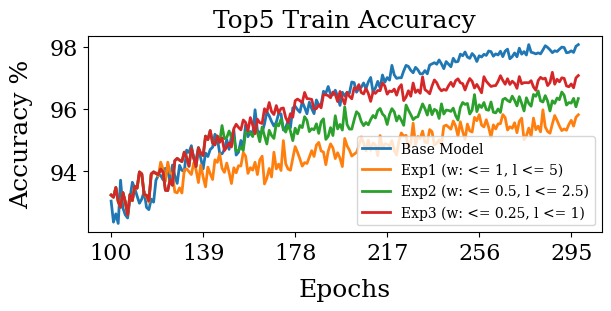

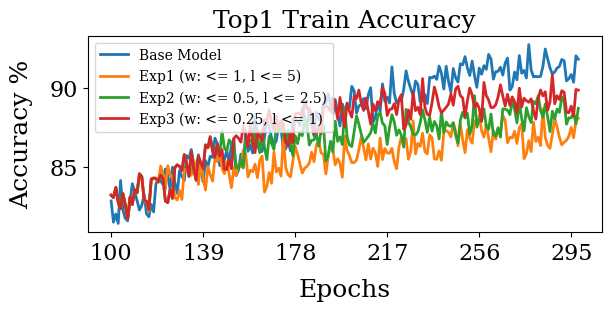

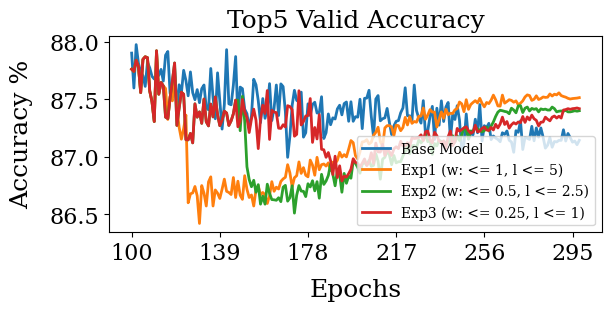

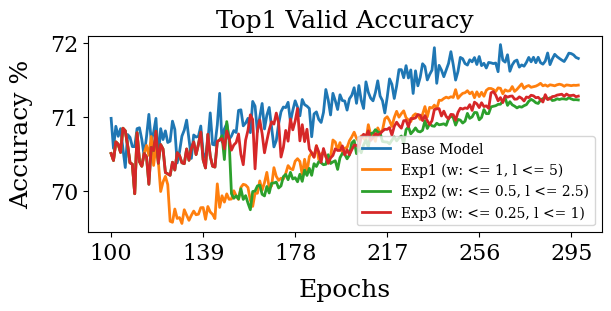

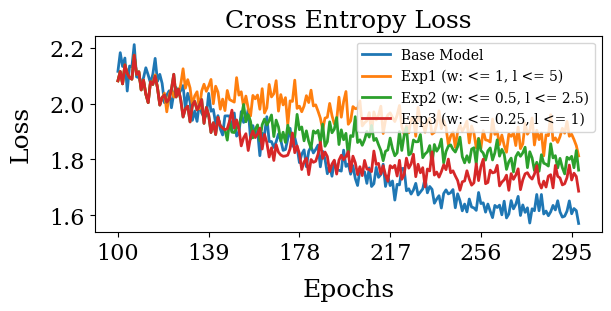

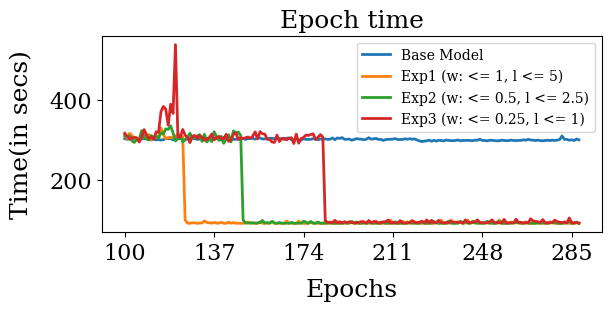

In [201]:
plot_values(train_top5_all, exp_1_full_train_t5, exp_2_full_train_t5, exp_4_full_train_t5, "Accuracy %", "Top5 Train Accuracy", "abl_top5_train")
plot_values(train_top1_all, exp_1_full_train_t1, exp_2_full_train_t1, exp_4_full_train_t1, "Accuracy %", "Top1 Train Accuracy", "abl_top1_train", 100)
plot_values(valid_top5_all, exp_1_full_valid_t5, exp_2_full_valid_t5, exp_4_full_valid_t5, "Accuracy %", "Top5 Valid Accuracy", "abl_top5_valid")
plot_values(valid_top1_all, exp_1_full_valid_t1, exp_2_full_valid_t1, exp_4_full_valid_t1, "Accuracy %", "Top1 Valid Accuracy", "abl_top1_valid", 100)
plot_values(train_loss_all, exp_1_full_loss, exp_2_full_loss, exp_4_full_loss, "Loss", "Cross Entropy Loss", "abl_loss")
plot_values(remove_outlier(train_epoch_time_all), remove_outlier(exp_1_full_epoch_time), remove_outlier(exp_2_full_epoch_time), remove_outlier(exp_4_full_epoch_time), "Time(in secs)", "Epoch time", "abl_epoch")


In [212]:
def plot_warmup_values(base, exp_1, exp_2, exp_3, y_label, title= "", start_epoch=125, filename="", draw_line=False):
    # Determine minimum length after start_epoch
    min_len = min(len(base) - start_epoch,
                  len(exp_1) - start_epoch,
                  len(exp_2) - start_epoch,
                  len(exp_3) - start_epoch)
    
    # X-axis values reflect actual epochs
    x = range(start_epoch, start_epoch + min_len)

    fig,ax = plt.subplots(figsize=(5,3), constrained_layout=True)

    ax.plot(x, base[start_epoch:start_epoch+min_len], label="Base", linewidth=2)
    ax.plot(x, exp_2[start_epoch:start_epoch+min_len], label="5", linewidth=2)
    ax.plot(x, exp_1[start_epoch:start_epoch+min_len], label="10", linewidth=2)
    ax.plot(x, exp_3[start_epoch:start_epoch+min_len], label="15", linewidth=2)

    ax.set_xlabel("Epochs", fontsize=18)
    ax.set_title(f"{title}", fontsize=18)
    ax.set_ylabel(f"{y_label}", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(loc="lower right")
    
    if draw_line:
        ax.axvline(x=141, color='gray', linestyle='--', linewidth=2)
        ax.axvline(x=160, color='gray', linestyle='--', linewidth=2)

    plt.show()

    fig.savefig(f"{filename}.pdf")  # keep consistent width

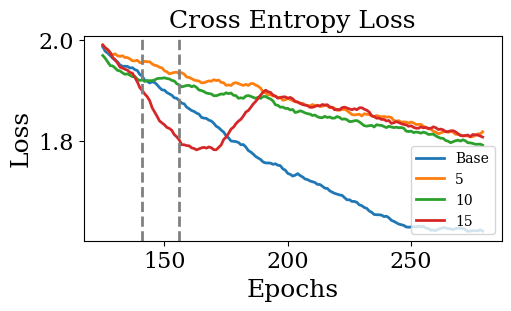

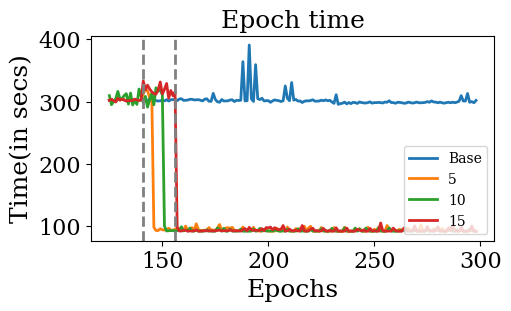

In [211]:
def moving_average(arr, window=20):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

# plot_warmup_values(moving_average(train_top1_all), moving_average(exp_2_full_train_t1), moving_average(exp_5_full_train_t1), moving_average(exp_6_full_train_t1), "Accuracy %", "Top1 Train Accuracy")
# plot_warmup_values(moving_average(valid_top1_all), moving_average(exp_2_full_valid_t1), moving_average(exp_5_full_valid_t1), moving_average(exp_6_full_valid_t1), "Accuracy %", "Top1 Valid Accuracy")
plot_warmup_values(moving_average(train_loss_all), moving_average(exp_2_full_loss), moving_average(exp_5_full_loss), moving_average(exp_6_full_loss), "Loss", "Cross Entropy Loss", 125,'warmup_loss', draw_line = True)
plot_warmup_values(train_epoch_time_all, exp_2_full_epoch_time, exp_5_full_epoch_time, exp_6_full_epoch_time, "Time(in secs)", "Epoch time",125,'warmup_speedup', draw_line= False)

# plot_warmup_values(remove_outlier(train_epoch_time_all[120:]), remove_outlier(exp_2_full_epoch_time[120:]), remove_outlier(exp_5_full_epoch_time[120:]), remove_outlier(exp_6_full_epoch_time[120:]), "Time(in secs)", "Epoch time")


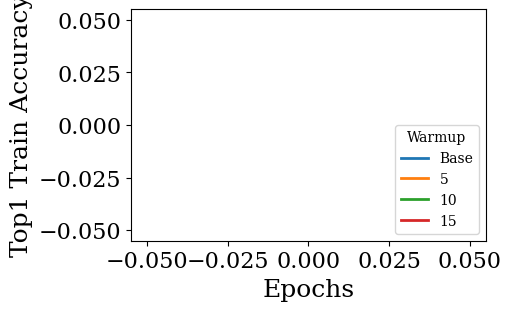

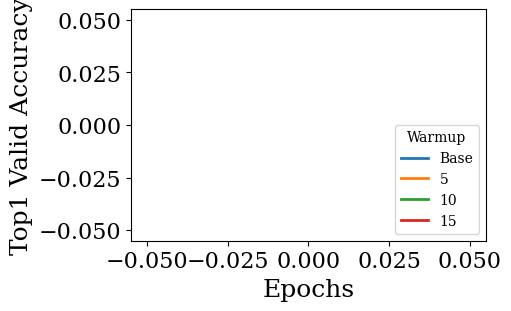

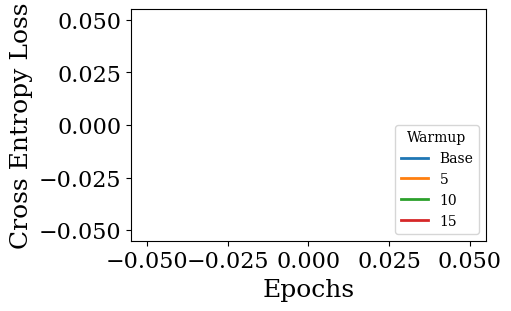

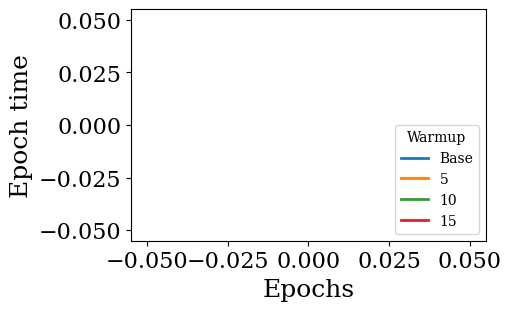

In [204]:
# plot_warmup_values(moving_average(exp_2_full_train_t5[135:]), moving_average(exp_5_full_train_t5[135:]), moving_average(exp_6_full_train_t5[135:]), "Accuracy %", "Top5 Train Accuracy")
plot_warmup_values(moving_average(exp_2_full_train_t1[135:]), moving_average(exp_5_full_train_t1[135:]), moving_average(exp_6_full_train_t1[135:]), "Accuracy %", "Top1 Train Accuracy")
# plot_warmup_values(moving_average(exp_2_full_valid_t5[135:]), moving_average(exp_5_full_valid_t5[135:]), moving_average(exp_6_full_valid_t5[135:]), "Accuracy %", "Top5 Valid Accuracy")
plot_warmup_values(moving_average(exp_2_full_valid_t1[135:]), moving_average(exp_5_full_valid_t1[135:]), moving_average(exp_6_full_valid_t1[135:]), "Accuracy %", "Top1 Valid Accuracy")
plot_warmup_values(moving_average(exp_2_full_loss[135:]), moving_average(exp_5_full_loss[135:]), moving_average(exp_6_full_loss[135:]), "Loss", "Cross Entropy Loss")
plot_warmup_values(remove_outlier(exp_2_full_epoch_time[135:]), remove_outlier(exp_5_full_epoch_time[135:]), remove_outlier(exp_6_full_epoch_time[135:]), "Time(in secs)", "Epoch time")


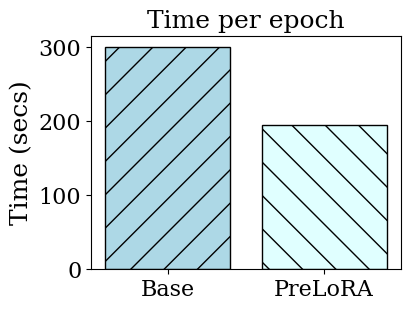

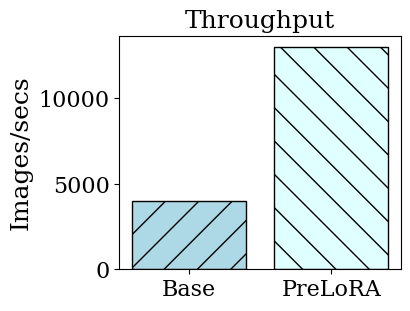

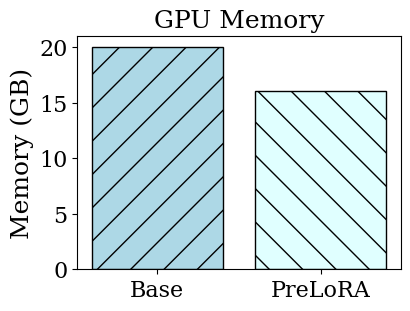

In [205]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

# Categories and hatch patterns
categories = ['Base', 'PreLoRA']
hatches = ['/', '\\']  # '/' for Before, '\' for After

# Function to create a styled bar chart
def plot_bar_chart(values, title, y_label, colors, filename):
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)  # assign to fig
    bars = ax.bar(categories, values, color=colors, edgecolor='black')
    
    # Apply consistent hatch patterns
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
        
    # Styling
    ax.set_ylabel(y_label, fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    
    # Save first, then show
    fig.savefig(f"{filename}.pdf", bbox_inches='tight')  # save correctly
    plt.show()  # display
    plt.close(fig)  # close to free memory

    

# 1. Epoch Time (secs) - light blue
plot_bar_chart([300, 195], "Time per epoch", "Time (secs)", ['lightblue','lightcyan'], 'time')

# 2. Training Images per Epoch - light orange
plot_bar_chart([4000, 13000], "Throughput", "Images/secs", ['lightblue','lightcyan'], 'compute')

# 3. GPU Memory (GB) - light green
plot_bar_chart([20, 16], "GPU Memory", "Memory (GB)", ['lightblue','lightcyan'], 'memory')
